### Setup and Library Imports

This cell imports necessary libraries for data manipulation, visualization, and machine learning tasks. It includes `pandas` for data handling, `numpy` for numerical operations, `matplotlib.pyplot` and `seaborn` for plotting, `sklearn.model_selection` for splitting data, `sklearn.preprocessing` for data scaling, and `warnings` to suppress minor warnings.

In [43]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

### Load Taiwan Credit Card Default Data

This cell loads the 'default of credit card clients.xls' Excel file into a pandas DataFrame called `taiwan`. The `header=1` argument specifies that the second row (index 1) of the Excel file should be used as the column headers. Finally, it displays the first 10 rows of the loaded DataFrame to give a quick overview of the data.

In [44]:
taiwan = pd.read_excel('/content/default of credit card clients.xls', header=1)

taiwan.head(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,6,50000,1,1,2,37,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
6,7,500000,1,1,2,29,0,0,0,0,...,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
7,8,100000,2,2,2,23,0,-1,-1,0,...,221,-159,567,380,601,0,581,1687,1542,0
8,9,140000,2,3,1,28,0,0,2,0,...,12211,11793,3719,3329,0,432,1000,1000,1000,0
9,10,20000,1,3,2,35,-2,-2,-2,-2,...,0,13007,13912,0,0,0,13007,1122,0,0


### Initial Data Inspection (Taiwan Data)

This cell provides a quick initial inspection of the `taiwan` DataFrame. It prints:
- The shape of the DataFrame (number of rows and columns).
- The list of column names.
- A concise summary of the DataFrame, including data types of each column, non-null values, and memory usage, using `taiwan.info()`.

In [45]:
print("Shape:")
print(taiwan.shape)

print("\nColumns:")
print(taiwan.columns)

print("\nInfo:")
taiwan.info()

Shape:
(30000, 25)

Columns:
Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2

### Descriptive Statistics (Taiwan Data)

This cell generates descriptive statistics for the `taiwan` DataFrame using `taiwan.describe()`. This provides a summary of the central tendency, dispersion, and shape of the distribution for numerical columns, including count, mean, standard deviation, minimum, maximum, and quartile values.

In [46]:
taiwan.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


### Rename Target Column (Taiwan Data)

This cell renames the target column from `'default payment next month'` to a simpler and more consistent `'DEFAULT'` in the `taiwan` DataFrame. The `inplace=True` argument ensures that the changes are applied directly to the DataFrame.

In [47]:
taiwan.rename(
    columns={
        "default payment next month":"DEFAULT"
    },
    inplace=True
)

### Verify Column Renaming (Taiwan Data)

This cell displays the updated column names of the `taiwan` DataFrame to confirm that the `default payment next month` column has been successfully renamed to `DEFAULT`.

In [48]:
taiwan.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT'],
      dtype='object')

### Check for Missing Values (Taiwan Data)

This cell checks for the presence of missing (null) values in each column of the `taiwan` DataFrame using `taiwan.isnull().sum()`. The output shows the total count of null values for every column.

In [49]:
print(
    taiwan.isnull().sum()
)

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64


### Calculate Percentage of Missing Values (Taiwan Data)

This cell calculates and prints the percentage of missing values for each column in the `taiwan` DataFrame. It divides the sum of null values by the total number of rows and multiplies by 100 to get a percentage.

In [50]:
missing = (
    taiwan.isnull().sum()
    /
    len(taiwan)
)*100

print(missing)

ID           0.0
LIMIT_BAL    0.0
SEX          0.0
EDUCATION    0.0
MARRIAGE     0.0
AGE          0.0
PAY_0        0.0
PAY_2        0.0
PAY_3        0.0
PAY_4        0.0
PAY_5        0.0
PAY_6        0.0
BILL_AMT1    0.0
BILL_AMT2    0.0
BILL_AMT3    0.0
BILL_AMT4    0.0
BILL_AMT5    0.0
BILL_AMT6    0.0
PAY_AMT1     0.0
PAY_AMT2     0.0
PAY_AMT3     0.0
PAY_AMT4     0.0
PAY_AMT5     0.0
PAY_AMT6     0.0
DEFAULT      0.0
dtype: float64


### Check for Duplicate Rows (Taiwan Data)

This cell checks for the presence of duplicate rows in the `taiwan` DataFrame. It prints the total count of rows that are exact duplicates of earlier rows.

In [51]:
print(
    "Duplicates:",
    taiwan.duplicated().sum()
)

Duplicates: 0


### Drop Duplicate Rows (Taiwan Data)

This cell removes any duplicate rows from the `taiwan` DataFrame. The `inplace=True` argument ensures that the DataFrame is modified directly, and `drop_duplicates` keeps the first occurrence of each row by default.

In [52]:
taiwan.drop_duplicates(
    inplace=True
)

### Drop 'ID' Column (Taiwan Data)

This cell drops the 'ID' column from the `taiwan` DataFrame. The 'ID' column is typically a unique identifier and not useful for machine learning models, so it's often removed during data preprocessing. The `inplace=True` argument applies the change directly to the DataFrame.

In [53]:
taiwan.drop(
    columns=["ID"],
    inplace=True
)

### Load German Credit Data

This cell loads the 'german.data-numeric' CSV file into a pandas DataFrame called `german`. It uses `delim_whitespace=True` to handle variable spacing as a delimiter and `header=None` because the file does not have a header row, so column names will be assigned numerically.

In [54]:
german = pd.read_csv(
    '/content/german.data-numeric',
    delim_whitespace=True,
    header=None
)


### Assign Column Names and Display Head (German Data)

This cell assigns meaningful names to the columns of the `german` DataFrame. The original file did not have a header, so generic or feature-specific names are given to improve readability and understanding. After assigning names, it displays the first 10 rows of the DataFrame to show the new column headers and the data content.

In [55]:
german.columns = ["Status_Checking", "Duration", "Credit_History", "Purpose",
    "Credit_Amount","Savings","Employment", "Installment_Rate",
    "Personal_Status", "Other_Debtors", "Residence_Since", "Property", "Age",
    "Other_Installment_Plans", "Housing", "Existing_Credits", "Job",
    "Dependents","Telephone","Foreign_Worker",
    "Feature21", "Feature22", "Feature23", "Feature24",
    "DEFAULT"
]

german.head(10)

,Status_Checking,Duration,Credit_History,Purpose,Credit_Amount,Savings,Employment,Installment_Rate,Personal_Status,Other_Debtors,...,Existing_Credits,Job,Dependents,Telephone,Foreign_Worker,Feature21,Feature22,Feature23,Feature24,DEFAULT
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2
5,4,36,2,91,5,3,3,4,4,35,...,0,0,1,0,0,0,0,1,0,1
6,4,24,2,28,3,5,3,4,2,53,...,0,0,1,0,0,1,0,0,1,1
7,2,36,2,69,1,3,3,2,3,35,...,0,1,1,0,1,0,0,0,0,1
8,4,12,2,31,4,4,1,4,1,61,...,0,0,1,0,0,1,0,1,0,1
9,2,30,4,52,1,1,4,2,3,28,...,1,0,1,0,0,1,0,0,0,2


### Map 'DEFAULT' Column Values (German Data)

This cell re-maps the values in the 'DEFAULT' column of the `german` DataFrame. It replaces `1` with `0` (indicating non-default) and `2` with `1` (indicating default). This standardization is often done to ensure consistent binary target variable representation (0 for negative class, 1 for positive class).

In [56]:
german["DEFAULT"] = (
    german["DEFAULT"]
    .replace({1:0,2:1})
)

### Descriptive Statistics (German Data)

This cell generates descriptive statistics for the `german` DataFrame using `german.describe()`. Similar to the Taiwan dataset, this provides a summary of numerical features, including count, mean, standard deviation, minimum, maximum, and quartile values, helping to understand the distribution and potential outliers.

In [57]:
german.describe()

,Status_Checking,Duration,Credit_History,Purpose,Credit_Amount,Savings,Employment,Installment_Rate,Personal_Status,Other_Debtors,...,Existing_Credits,Job,Dependents,Telephone,Foreign_Worker,Feature21,Feature22,Feature23,Feature24,DEFAULT
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000
mean,2.577000,20.903000,2.54500,32.711000,2.105000,3.384000,2.68200,2.845000,2.358000,35.546000,...,0.234000,0.103000,0.907000,0.041000,0.179000,0.713000,0.022000,0.2000,0.630000,0.300000
std,1.257638,12.058814,1.08312,28.252605,1.580023,1.208306,0.70808,1.103718,1.050209,11.375469,...,0.423584,0.304111,0.290578,0.198389,0.383544,0.452588,0.146757,0.4002,0.483046,0.458487
min,1.000000,4.000000,0.00000,2.000000,1.000000,1.000000,1.00000,1.000000,1.000000,19.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
25%,1.000000,12.000000,2.00000,14.000000,1.000000,3.000000,2.00000,2.000000,1.000000,27.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
50%,2.000000,18.000000,2.00000,23.000000,1.000000,3.000000,3.00000,3.000000,2.000000,33.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0000,1.000000,0.000000
75%,4.000000,24.000000,4.00000,40.000000,3.000000,5.000000,3.00000,4.000000,3.000000,42.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0000,1.000000,1.000000
max,4.000000,72.000000,4.00000,184.000000,5.000000,5.000000,4.00000,4.000000,4.000000,75.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.000000,1.000000


### Visualize Taiwan Default Distribution

This cell creates a count plot to visualize the distribution of the 'DEFAULT' target variable in the `taiwan` DataFrame. It uses `seaborn.countplot` to show the number of clients who defaulted versus those who did not, providing an insight into class imbalance. The plot is titled 'Taiwan Default Distribution'.

# Target Distribution

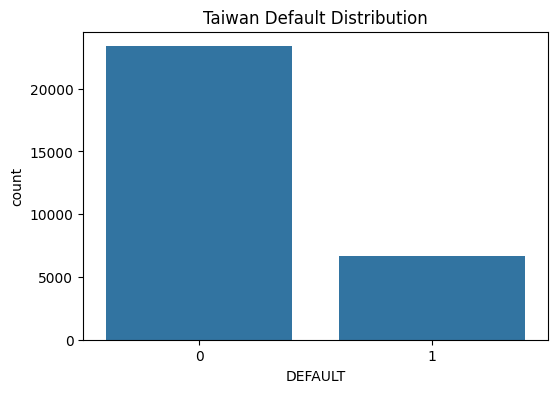

In [58]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="DEFAULT",
    data=taiwan
)

plt.title(
    "Taiwan Default Distribution"
)

plt.show()

### Visualize German Default Distribution

This cell generates a count plot to visualize the distribution of the 'DEFAULT' target variable in the `german` DataFrame. Similar to the Taiwan dataset visualization, it uses `seaborn.countplot` to display the counts of each class in the 'DEFAULT' column, helping to understand the class balance. The plot is titled 'German Default Distribution'.

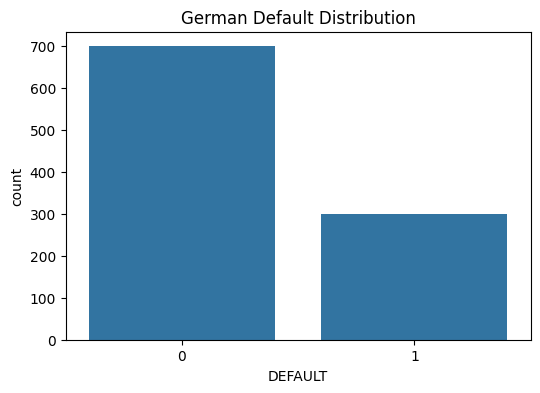

In [59]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="DEFAULT",
    data=german
)

plt.title(
    "German Default Distribution"
)

plt.show()

### Percentage Distribution of Taiwan Default

This cell calculates and prints the percentage distribution of the 'DEFAULT' target variable in the `taiwan` DataFrame. It shows the proportion of clients who defaulted (1) versus those who did not (0), providing a numerical overview of the class imbalance.

In [60]:
print(
    taiwan["DEFAULT"]
    .value_counts(normalize=True)*100
)

DEFAULT
0    77.88
1    22.12
Name: proportion, dtype: float64


### Percentage Distribution of German Default

Similar to the Taiwan dataset, this cell calculates and prints the percentage distribution of the 'DEFAULT' target variable in the `german` DataFrame. This provides a numerical summary of the class balance within the German credit data.

In [61]:
print(
    german["DEFAULT"]
    .value_counts(normalize=True)*100
)

DEFAULT
0    70.0
1    30.0
Name: proportion, dtype: float64


### Taiwan Correlation Matrix

This cell generates and displays a heatmap of the correlation matrix for the `taiwan` DataFrame. A correlation matrix helps visualize the linear relationships between all pairs of numerical variables. The `coolwarm` colormap is used to easily distinguish positive and negative correlations.

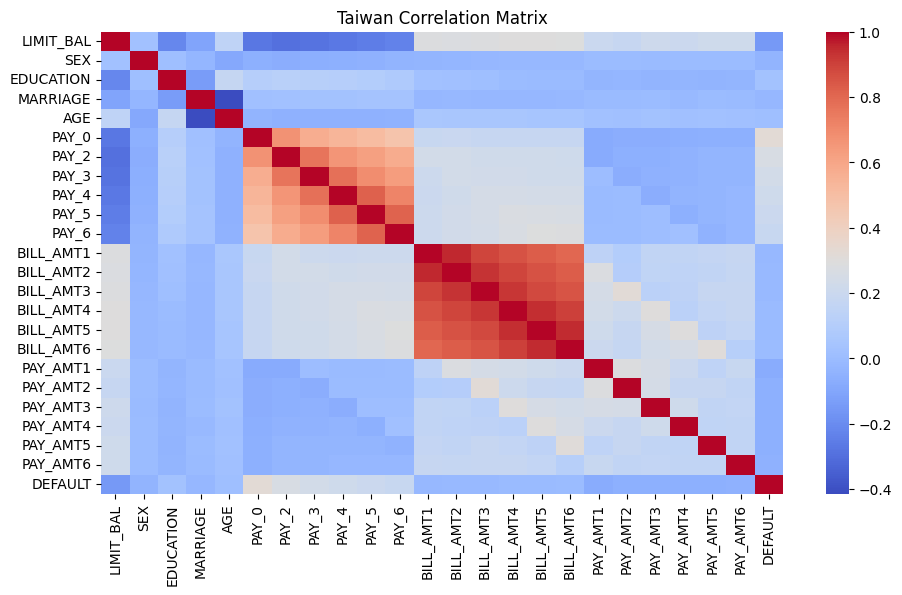

In [64]:
plt.figure(
    figsize=(11,6)
)

sns.heatmap(
    taiwan.corr(),
    cmap="coolwarm"
)

plt.title(
    "Taiwan Correlation Matrix"
)

plt.show()

### German Correlation Matrix

This cell generates and displays a heatmap of the correlation matrix for the `german` DataFrame. Similar to the Taiwan dataset, this visualization helps understand the linear relationships between the features in the German credit data, using the `coolwarm` colormap for clarity.

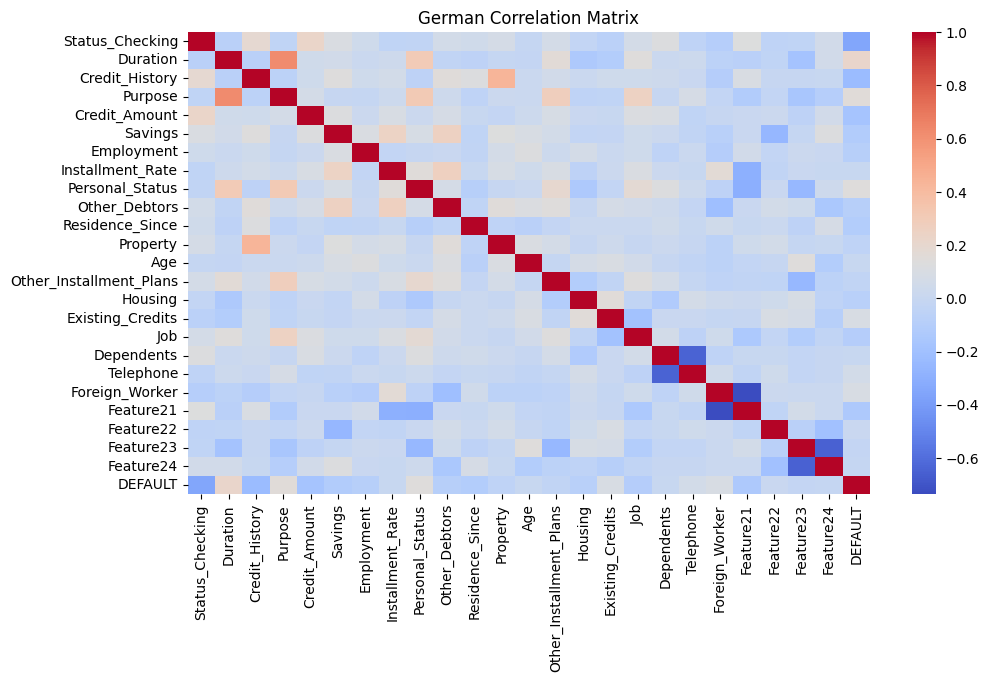

In [66]:
plt.figure(
    figsize=(11,6)
)

sns.heatmap(
    german.corr(),
    cmap="coolwarm"
)

plt.title(
    "German Correlation Matrix"
)

plt.show()

### Distribution of Key Features (Taiwan Data)

This cell generates histograms for two key numerical features, 'LIMIT_BAL' (credit limit) and 'AGE', from the `taiwan` DataFrame. Histograms with a Kernel Density Estimate (KDE) line help visualize the distribution of these variables, showing their spread, central tendency, and any skewness or outliers.

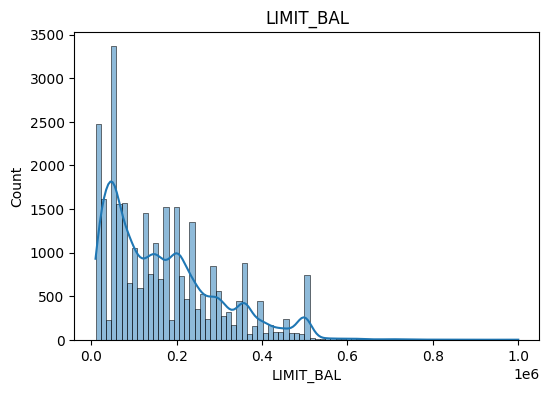

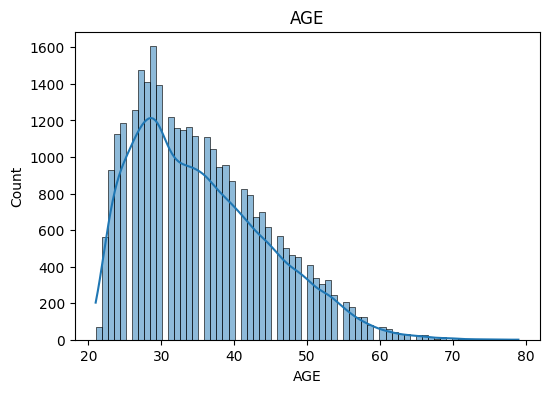

In [67]:
features = [
    "LIMIT_BAL",
    "AGE"
]

for col in features:

    plt.figure(figsize=(6,4))

    sns.histplot(
        taiwan[col],
        kde=True
    )

    plt.title(col)

    plt.show()

### Relationship between LIMIT_BAL and DEFAULT (Taiwan Data)

This cell creates a box plot to visualize the relationship between 'LIMIT_BAL' (credit limit) and the 'DEFAULT' target variable in the `taiwan` DataFrame. Box plots are useful for showing the distribution of a numerical variable across different categories of a categorical variable, helping to identify if there are differences in credit limits between those who defaulted and those who did not.

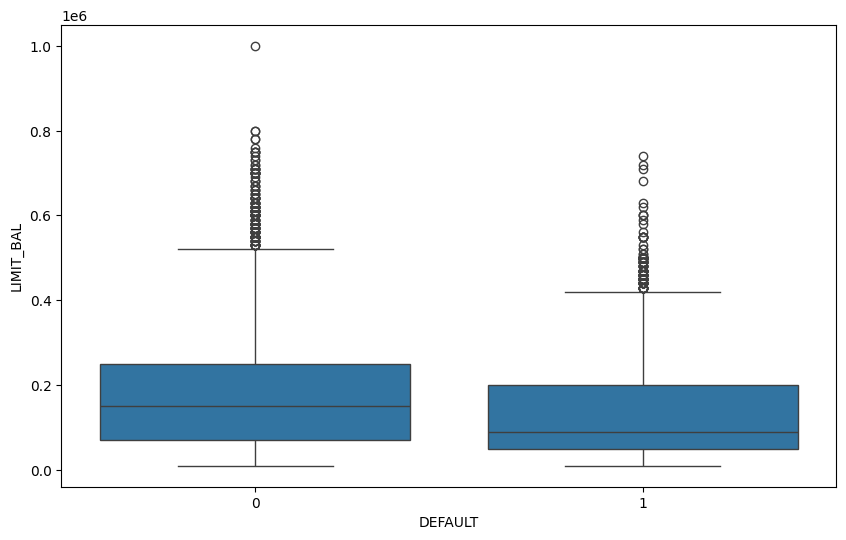

In [68]:
plt.figure(
    figsize=(10,6)
)

sns.boxplot(
    x="DEFAULT",
    y="LIMIT_BAL",
    data=taiwan
)

plt.show()

### Save Cleaned Taiwan Data

This cell saves the processed `taiwan` DataFrame to a new CSV file named `cleaned_taiwan.csv`. The `index=False` argument prevents pandas from writing the DataFrame index as a column in the CSV file, which is often desirable for clean data exports.

In [69]:
taiwan.to_csv(
    "cleaned_taiwan.csv",
    index=False
)

### Save Cleaned German Data

This cell saves the processed `german` DataFrame to a new CSV file named `cleaned_german.csv`. Similar to the Taiwan data, `index=False` is used to avoid writing the DataFrame index to the CSV file, ensuring a clean and model-ready dataset.

In [70]:
german.to_csv(
    "cleaned_german.csv",
    index=False
)